# Chapter 14 Python Lab  
## Double Integrals over General Regions

This lab accompanies **Chapter 14: Double Integrals over General Regions**.

Rectangles are the easiest base regions for double integrals, but most meaningful regions are not rectangles.  
A general double integral

$$
\iint_D f(x,y)\,dA
$$

requires two decisions:

1. how to describe the region $D$;
2. which order of integration makes the problem easier.

This lab uses Python to explore:

- Type I regions with vertical slices;
- Type II regions with horizontal slices;
- reversing the order of integration;
- splitting regions into simpler pieces;
- area by $\iint_D 1\,dA$;
- volume under a surface over a curved region;
- mass, density, and average value;
- probability over triangular and curved events;
- numerical integration over irregular regions;
- Monte Carlo integration;
- and computational workflows for region-based integration.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. identify and visualize Type I and Type II regions;
2. build numerical iterated integrals with variable limits;
3. reverse integration order for a given region;
4. compute area using a double integral of $1$;
5. split regions when one set of limits is not enough;
6. compute volume over nonrectangular regions;
7. compute mass and average value from density functions;
8. evaluate probabilities over two-dimensional events;
9. approximate integrals over irregular regions using masks;
10. compare deterministic grid methods with Monte Carlo methods.

## Source note

This notebook was generated from the uploaded Chapter 14 QMD file.  
The extracted early headings from the source file include:

- Learning objectives
- 14.1 Why rectangles are not enough
- 14.2 Type I regions: vertical slicing
- Double integral over a Type I region
- Example 14.1: A region between a parabola and a line
- 14.3 Type II regions: horizontal slicing
- Double integral over a Type II region
- Example 14.2: A region between $x=y$ and $x=y^2$
- 14.4 How to choose the order of integration
- Geometry first, algebra second
- 14.5 Reversing the order of integration
- Example 14.3: From region to reversed integral
- 14.6 Area of a plane region
- Area by double integral

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def make_grid(xmin, xmax, ymin, ymax, n=300):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def make_3d_axes(title=None, elev=30, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def iterated_type1(f, a, b, lower, upper, nx=600, ny=400):
    """
    Approximate ∫_a^b ∫_{lower(x)}^{upper(x)} f(x,y) dy dx.
    """
    xs = np.linspace(a, b, nx)
    inner = np.zeros_like(xs, dtype=float)
    for i, x0 in enumerate(xs):
        y0 = lower(x0)
        y1 = upper(x0)
        ys = np.linspace(y0, y1, ny)
        inner[i] = np.trapezoid(safe_eval_2d(lambda X, Y: f(X, Y), x0*np.ones_like(ys), ys), ys)
    return float(np.trapezoid(inner, xs)), xs, inner

def iterated_type2(f, c, d, left, right, ny=600, nx=400):
    """
    Approximate ∫_c^d ∫_{left(y)}^{right(y)} f(x,y) dx dy.
    """
    ys = np.linspace(c, d, ny)
    inner = np.zeros_like(ys, dtype=float)
    for i, y0 in enumerate(ys):
        x0 = left(y0)
        x1 = right(y0)
        xs = np.linspace(x0, x1, nx)
        inner[i] = np.trapezoid(safe_eval_2d(lambda X, Y: f(X, Y), xs, y0*np.ones_like(xs)), xs)
    return float(np.trapezoid(inner, ys)), ys, inner

def midpoint_region(f, xmin, xmax, ymin, ymax, mask, nx=400, ny=400):
    """
    Midpoint approximation over an arbitrary masked region inside a bounding box.
    """
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    xmid = xmin + (np.arange(nx) + 0.5)*dx
    ymid = ymin + (np.arange(ny) + 0.5)*dy
    X, Y = np.meshgrid(xmid, ymid)
    inside = mask(X, Y)
    Z = safe_eval_2d(f, X, Y)
    val = np.sum(Z[inside])*dx*dy
    return float(val), X, Y, Z, inside, dx, dy

def monte_carlo_region(f, xmin, xmax, ymin, ymax, mask, n=100_000, seed=0):
    """
    Monte Carlo estimate of ∫∫_D f dA, where D is described by mask.
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(xmin, xmax, n)
    Y = rng.uniform(ymin, ymax, n)
    inside = mask(X, Y)
    values = np.zeros(n, dtype=float)
    values[inside] = safe_eval_2d(f, X[inside], Y[inside])
    box_area = (xmax - xmin)*(ymax - ymin)
    est = box_area*np.mean(values)
    se = box_area*np.std(values, ddof=1)/np.sqrt(n)
    return float(est), float(se), X, Y, inside, values

def plot_type1_region(a, b, lower, upper, title="Type I region", n=400, slices=True):
    xs = np.linspace(a, b, n)
    lo = lower(xs)
    hi = upper(xs)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(xs, lo, linewidth=2, label="lower boundary")
    ax.plot(xs, hi, linewidth=2, label="upper boundary")
    ax.fill_between(xs, lo, hi, alpha=0.3)
    if slices:
        for x0 in np.linspace(a, b, 6)[1:-1]:
            ax.plot([x0, x0], [lower(x0), upper(x0)], linewidth=2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

def plot_type2_region(c, d, left, right, title="Type II region", n=400, slices=True):
    ys = np.linspace(c, d, n)
    le = left(ys)
    ri = right(ys)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(le, ys, linewidth=2, label="left boundary")
    ax.plot(ri, ys, linewidth=2, label="right boundary")
    ax.fill_betweenx(ys, le, ri, alpha=0.3)
    if slices:
        for y0 in np.linspace(c, d, 6)[1:-1]:
            ax.plot([left(y0), right(y0)], [y0, y0], linewidth=2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

def plot_mask_region(mask, xmin, xmax, ymin, ymax, title="Region", n=450):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    inside = mask(X, Y)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(X, Y, inside.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.45)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    plt.show()
    return X, Y, inside

def plot_surface_over_mask(f, mask, xmin, xmax, ymin, ymax, title="Surface over region", n=220,
                           elev=32, azim=45):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    inside = mask(X, Y)
    Zmasked = np.where(inside, Z, np.nan)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Zmasked, linewidth=0, alpha=0.85)
    plt.show()
    return X, Y, Zmasked

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-hkojtca4 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Why general regions require new limits

A rectangle has constant limits:

$$
a\le x\le b,\qquad c\le y\le d.
$$

A curved region often has variable limits.  
The main skill is to slice the region.

- **Vertical slices** lead to Type I descriptions.
- **Horizontal slices** lead to Type II descriptions.

## 1. A nonrectangular region bounded by a line and a parabola

Consider the region

$$
D=\{(x,y):0\le x\le1,\;3x\le y\le 4-x^2\}.
$$

This is a Type I region because each vertical slice has a lower and upper $y$-value.

In [2]:
lower = lambda x: 3*x
upper = lambda x: 4 - x**2

plot_type1_region(
    0, 1, lower, upper,
    title=r"Type I region: $0\le x\le1,\;3x\le y\le4-x^2$"
)

ValueError: 
0\le x\le1,\;3x\le y\le4-x^2
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x500 with 1 Axes>

## 2. Area of this region

The area is

$$
\iint_D 1\,dA
=
\int_0^1\int_{3x}^{4-x^2}1\,dy\,dx.
$$

Numerically, this can be evaluated as an iterated integral.

Area estimate: 2.1666664055977356
Exact area: 2.1666666666666665
Error: -2.6106893091792926e-07


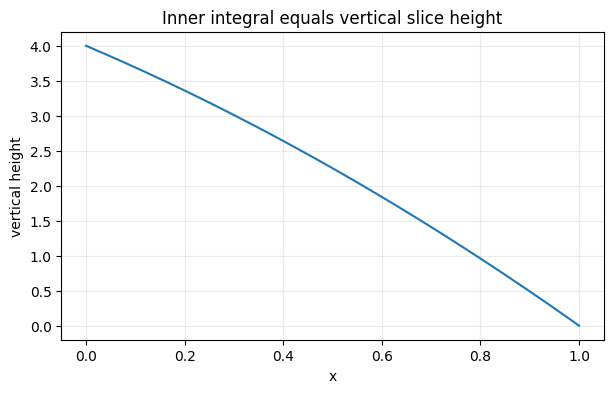

In [3]:
one = lambda X, Y: np.ones_like(np.asarray(X, dtype=float))

area_type1, xs, inner_heights = iterated_type1(
    one,
    0, 1,
    lower,
    upper,
    nx=800,
    ny=50
)

# Exact: ∫_0^1 [(4-x^2)-3x] dx = 4 - 1/3 - 3/2 = 13/6
exact_area = 13/6

print("Area estimate:", area_type1)
print("Exact area:", exact_area)
print("Error:", area_type1 - exact_area)

plt.figure(figsize=(7, 4))
plt.plot(xs, inner_heights)
plt.xlabel("x")
plt.ylabel("vertical height")
plt.title("Inner integral equals vertical slice height")
plt.grid(True, alpha=0.25)
plt.show()

## 3. Integrate a nonconstant function over the same region

Compute

$$
\iint_D 2xy\,dA.
$$

Integral estimate: 3.9166619236220077
Exact value: 3.9166666666666665
Error: -4.743044658805928e-06


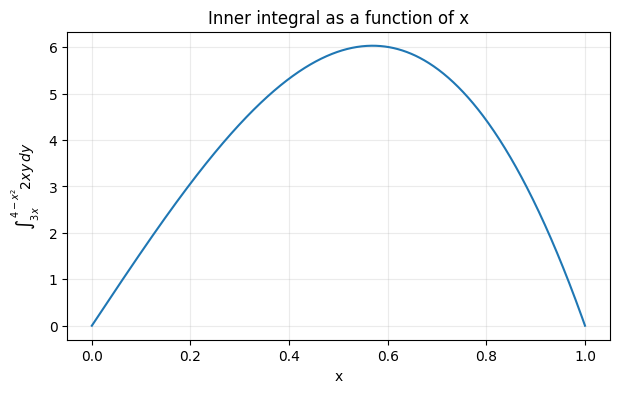

In [4]:
def f_example(X, Y):
    return 2*X*Y

val_type1, xs, inner_values = iterated_type1(
    f_example,
    0, 1,
    lower,
    upper,
    nx=900,
    ny=500
)

# Exact by symbolic hand calculation:
# ∫_0^1 ∫_{3x}^{4-x^2} 2xy dy dx = ∫_0^1 x[(4-x^2)^2-(3x)^2] dx
# = ∫_0^1 (16x - 17x^3 + x^5) dx = 8 - 17/4 + 1/6 = 47/12
exact_val = 47/12

print("Integral estimate:", val_type1)
print("Exact value:", exact_val)
print("Error:", val_type1 - exact_val)

plt.figure(figsize=(7, 4))
plt.plot(xs, inner_values)
plt.xlabel("x")
plt.ylabel(r"$\int_{3x}^{4-x^2}2xy\,dy$")
plt.title("Inner integral as a function of x")
plt.grid(True, alpha=0.25)
plt.show()

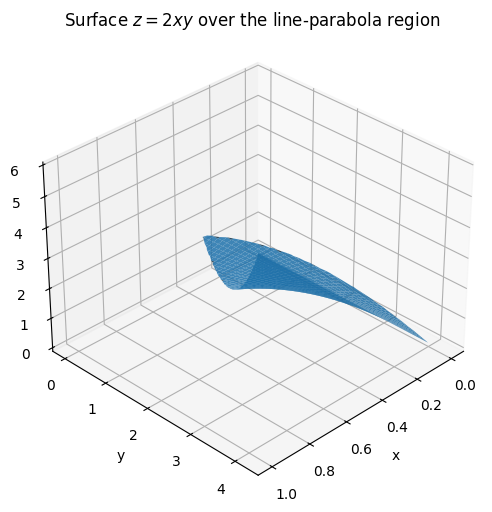

(array([[0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        ...,
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ]],
       shape=(220, 220)),
 array([[0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.019178, 0.019178, 0.019178, ..., 0.019178, 0.019178, 0.019178],
        [0.038356, 0.038356, 0.038356, ..., 0.038356, 0.038356, 0.038356],
        ...,
        [4.161644, 4.161644, 4.161644, ..., 4.161644, 4.161644, 4.161644],
        [4.180822, 4.180822, 4.180822, ..., 4.180822, 4.180822, 4.180822],
        [4.2     , 4.2     , 4.2     , ..., 4.2     , 4.2     , 4.2     ]],
       shape=(220, 220)),
 array([[0.      ,  

In [5]:
def mask_example(X, Y):
    return (0 <= X) & (X <= 1) & (3*X <= Y) & (Y <= 4 - X**2)

plot_surface_over_mask(
    f_example,
    mask_example,
    xmin=0, xmax=1, ymin=0, ymax=4.2,
    title=r"Surface $z=2xy$ over the line-parabola region"
)

---

# Part II. Type I regions

A Type I region has the form

$$
D=\{(x,y):a\le x\le b,\;p(x)\le y\le q(x)\}.
$$

The corresponding integral is

$$
\iint_D f(x,y)\,dA
=
\int_a^b\int_{p(x)}^{q(x)}f(x,y)\,dy\,dx.
$$

## 4. Region between $y=x^2$ and $y=x$

Let

$$
D=\{(x,y):0\le x\le1,\;x^2\le y\le x\}.
$$

This region is bounded by the parabola $y=x^2$ and the line $y=x$.

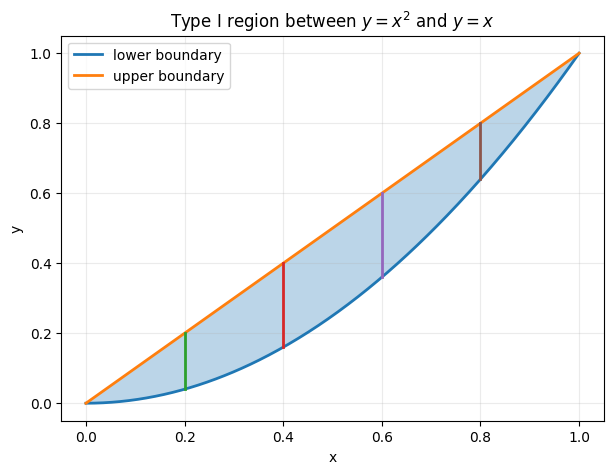

In [6]:
lower_B = lambda x: x**2
upper_B = lambda x: x

plot_type1_region(
    0, 1, lower_B, upper_B,
    title=r"Type I region between $y=x^2$ and $y=x$"
)

## 5. Area and average value over the region

Compute the area and average value of

$$
f(x,y)=x+y
$$

over the region.

In [7]:
def f_sum(X, Y):
    return X + Y

area_B, *_ = iterated_type1(one, 0, 1, lower_B, upper_B, nx=900, ny=80)
integral_B, xs, inner_B = iterated_type1(f_sum, 0, 1, lower_B, upper_B, nx=900, ny=500)

avg_B = integral_B/area_B

print("Area estimate:", area_B)
print("Exact area:", 1/6)
print("Integral of x+y estimate:", integral_B)
print("Average value estimate:", avg_B)

Area estimate: 0.1666664604473392
Exact area: 0.16666666666666666
Integral of x+y estimate: 0.14999979378069805
Average value estimate: 0.8999998762684035


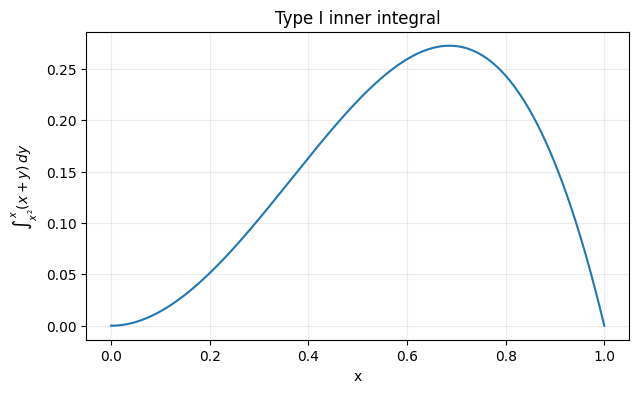

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(xs, inner_B)
plt.xlabel("x")
plt.ylabel(r"$\int_{x^2}^{x}(x+y)\,dy$")
plt.title("Type I inner integral")
plt.grid(True, alpha=0.25)
plt.show()

### Guided task 1

Use a Type I integral to compute

$$
\iint_D x^2\,dA
$$

where

$$
D=\{(x,y):0\le x\le2,\;0\le y\le 4-x^2\}.
$$

In [9]:
def task1_f(X, Y):
    return X**2

task1_lower = lambda x: 0*x
task1_upper = lambda x: 4 - x**2

task1_val, *_ = iterated_type1(
    task1_f,
    0, 2,
    task1_lower,
    task1_upper,
    nx=900,
    ny=300
)

# Exact: ∫_0^2 x^2(4-x^2) dx = 4*(8/3)-32/5 = 64/15
print("Numerical value:", task1_val)
print("Exact value:", 64/15)

Numerical value: 4.266660067649822
Exact value: 4.266666666666667


---

# Part III. Type II regions

A Type II region has the form

$$
D=\{(x,y):c\le y\le d,\;g(y)\le x\le h(y)\}.
$$

The corresponding integral is

$$
\iint_D f(x,y)\,dA
=
\int_c^d\int_{g(y)}^{h(y)}f(x,y)\,dx\,dy.
$$

## 6. Region between $x=y^2$ and $x=y$

Let

$$
D=\{(x,y):0\le y\le1,\;y^2\le x\le y\}.
$$

This is naturally Type II.

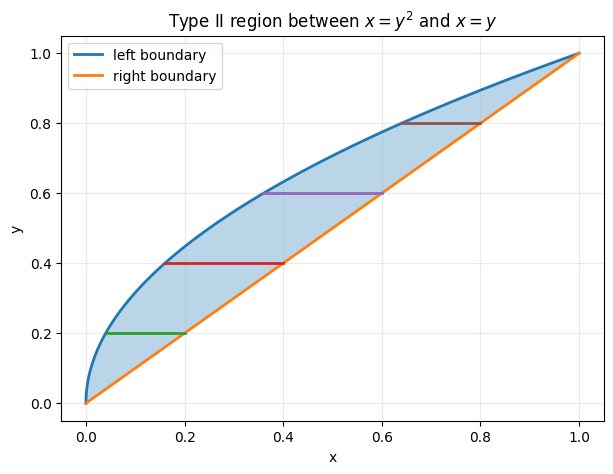

In [10]:
left_C = lambda y: y**2
right_C = lambda y: y

plot_type2_region(
    0, 1, left_C, right_C,
    title=r"Type II region between $x=y^2$ and $x=y$"
)

## 7. Integrate over this Type II region

Compute

$$
\iint_D (x+y)\,dA
=
\int_0^1\int_{y^2}^{y}(x+y)\,dx\,dy.
$$

Integral estimate: 0.14999979378069805
Exact value: 0.15
Error: -2.0621930194031357e-07


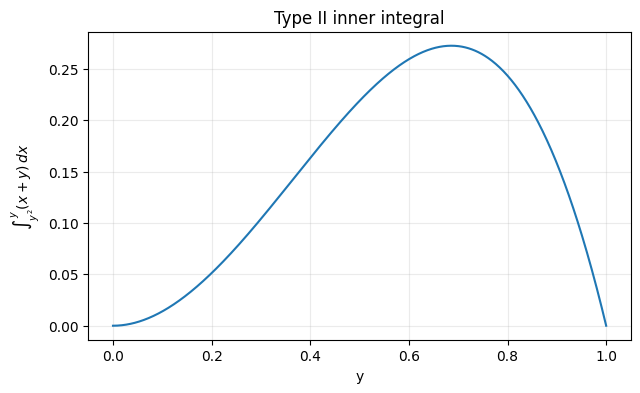

In [11]:
val_C, ys, inner_C = iterated_type2(
    f_sum,
    0, 1,
    left_C,
    right_C,
    ny=900,
    nx=500
)

# Exact:
# ∫_0^1 [x^2/2 + yx]_{y^2}^{y} dy
# = ∫_0^1 (3y^2/2 - y^4/2 - y^3) dy = 1/2 - 1/10 - 1/4 = 3/20
exact_C = 3/20

print("Integral estimate:", val_C)
print("Exact value:", exact_C)
print("Error:", val_C - exact_C)

plt.figure(figsize=(7, 4))
plt.plot(ys, inner_C)
plt.xlabel("y")
plt.ylabel(r"$\int_{y^2}^{y}(x+y)\,dx$")
plt.title("Type II inner integral")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Reversing the order of integration

Changing order means describing the same geometric region using a different slicing direction.

The region

$$
0\le x\le1,\qquad x^2\le y\le x
$$

can be rewritten as

$$
0\le y\le1,\qquad y\le x\le \sqrt y.
$$

This is often the most important skill in Chapter 14.

## 8. Verify both descriptions of the same region

Use

$$
f(x,y)=e^{y^2}.
$$

The Type I order

$$
\int_0^1\int_{x^2}^{x}e^{y^2}\,dy\,dx
$$

is awkward because $e^{y^2}$ has no elementary antiderivative in $y$.

The reversed order is

$$
\int_0^1\int_y^{\sqrt y}e^{y^2}\,dx\,dy
=
\int_0^1(\sqrt y-y)e^{y^2}\,dy.
$$

In [12]:
def f_exp_y2(X, Y):
    return np.exp(Y**2)

# Original Type I order
val_original, *_ = iterated_type1(
    f_exp_y2,
    0, 1,
    lambda x: x**2,
    lambda x: x,
    nx=500,
    ny=500
)

# Reversed Type II order
val_reversed, ys, inner_rev = iterated_type2(
    f_exp_y2,
    0, 1,
    lambda y: y,
    lambda y: np.sqrt(y),
    ny=900,
    nx=80
)

# Direct one-dimensional version after integrating over x:
ys_dense = np.linspace(0, 1, 2000)
direct_1d = np.trapezoid((np.sqrt(ys_dense) - ys_dense)*np.exp(ys_dense**2), ys_dense)

print("Original Type I numerical value:", val_original)
print("Reversed Type II numerical value:", val_reversed)
print("Direct 1D reduced value:", direct_1d)
print("Original minus reversed:", val_original - val_reversed)

Original Type I numerical value: 0.2115979717341234
Reversed Type II numerical value: 0.21159145850794117
Direct 1D reduced value: 0.2115968744060597
Original minus reversed: 6.5132261822253845e-06


In [13]:
plot_type1_region(
    0, 1,
    lambda x: x**2,
    lambda x: x,
    title=r"Same region as Type I: $x^2\le y\le x$"
)

plot_type2_region(
    0, 1,
    lambda y: y,
    lambda y: np.sqrt(y),
    title=r"Same region as Type II: $y\le x\le\sqrt y$"
)

ValueError: 
x^2\le y\le x
   ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 3), (line:1, col:4)

<Figure size 700x500 with 1 Axes>

ValueError: 
y\le x\le\sqrt y
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x500 with 1 Axes>

## 9. Region from integral limits

Consider the integral

$$
\int_0^4\int_{\sqrt y}^{2} f(x,y)\,dx\,dy.
$$

This describes

$$
0\le y\le4,\qquad \sqrt y\le x\le2.
$$

Since $x\ge\sqrt y$ means $y\le x^2$, the Type I form is

$$
0\le x\le2,\qquad 0\le y\le x^2.
$$

In [14]:
def f_demo(X, Y):
    return X + 2*Y

val_type2_demo, *_ = iterated_type2(
    f_demo,
    0, 4,
    lambda y: np.sqrt(y),
    lambda y: 2 + 0*y,
    ny=800,
    nx=400
)

val_type1_demo, *_ = iterated_type1(
    f_demo,
    0, 2,
    lambda x: 0*x,
    lambda x: x**2,
    nx=800,
    ny=400
)

print("Type II original value:", val_type2_demo)
print("Type I reversed value:", val_type1_demo)
print("Difference:", val_type2_demo - val_type1_demo)

plot_type2_region(
    0, 4,
    lambda y: np.sqrt(y),
    lambda y: 2 + 0*y,
    title=r"Original Type II region: $\sqrt y\le x\le 2$"
)

Type II original value: 10.399987559077212
Type I reversed value: 10.400022974063317
Difference: -3.5414986104598256e-05


ValueError: 
\sqrt y\le x\le 2
      ^
ParseSyntaxException: Expected \sqrt{value}, found 'y'  (at char 6), (line:1, col:7)

<Figure size 700x500 with 1 Axes>

---

# Part V. Splitting regions

Some regions cannot be described by a single Type I or Type II description without changing boundary formulas.

A common strategy is:

1. sketch the region;
2. decide where the top/bottom or left/right boundary changes;
3. split into simpler pieces;
4. add the resulting integrals.

## 10. A region that requires splitting in vertical slices

Consider the region inside the unit disk and above the line $y=0.5$:

$$
D=\{(x,y):x^2+y^2\le1,\;y\ge0.5\}.
$$

As a Type I region, the $x$-limits are

$$
-\sqrt{1-0.5^2}\le x\le \sqrt{1-0.5^2},
$$

and the vertical slice is

$$
0.5\le y\le \sqrt{1-x^2}.
$$

As a Type II region, it is simpler:

$$
0.5\le y\le1,\qquad -\sqrt{1-y^2}\le x\le \sqrt{1-y^2}.
$$

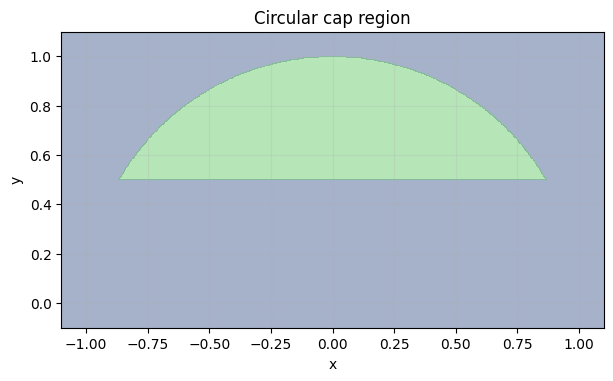

Area by Type II: 0.6141771668608892
Area by mask midpoint: 0.6141333333333334
Exact circular cap area: 0.6141848493043783


In [15]:
def cap_mask(X, Y):
    return (X**2 + Y**2 <= 1) & (Y >= 0.5)

plot_mask_region(cap_mask, -1.1, 1.1, -0.1, 1.1, title="Circular cap region")

# Area using Type II formula
cap_area_type2, ys, inner_cap = iterated_type2(
    one,
    0.5, 1,
    lambda y: -np.sqrt(1-y**2),
    lambda y:  np.sqrt(1-y**2),
    ny=900,
    nx=80
)

# Area using midpoint mask
cap_area_mask, *_ = midpoint_region(one, -1, 1, 0.5, 1, cap_mask, nx=600, ny=600)

# Exact circular segment area: arccos(a) - a sqrt(1-a^2), a=0.5
exact_cap_area = np.arccos(0.5) - 0.5*np.sqrt(1-0.5**2)

print("Area by Type II:", cap_area_type2)
print("Area by mask midpoint:", cap_area_mask)
print("Exact circular cap area:", exact_cap_area)

## 11. Splitting a region under a V-shaped top boundary

Let

$$
D=\{(x,y):-1\le x\le1,\;0\le y\le1-|x|\}.
$$

The top boundary changes formula at $x=0$, so a Type I integral naturally splits:

$$
\int_{-1}^0\int_0^{1+x}f(x,y)\,dy\,dx
+
\int_0^1\int_0^{1-x}f(x,y)\,dy\,dx.
$$

In [16]:
def v_mask(X, Y):
    return (-1 <= X) & (X <= 1) & (0 <= Y) & (Y <= 1 - np.abs(X))

def f_v(X, Y):
    return X**2 + Y

plot_mask_region(v_mask, -1.2, 1.2, -0.1, 1.1, title=r"V-shaped triangular region $0\le y\le1-|x|$")

left_val, *_ = iterated_type1(
    f_v,
    -1, 0,
    lambda x: 0*x,
    lambda x: 1 + x,
    nx=500,
    ny=300
)

right_val, *_ = iterated_type1(
    f_v,
    0, 1,
    lambda x: 0*x,
    lambda x: 1 - x,
    nx=500,
    ny=300
)

split_val = left_val + right_val
mask_val, *_ = midpoint_region(f_v, -1, 1, 0, 1, v_mask, nx=700, ny=700)

print("Split Type I value:", split_val)
print("Mask midpoint value:", mask_val)
print("Difference:", split_val - mask_val)

ValueError: 
0\le y\le1-|x|
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x600 with 1 Axes>

Split Type I value: 0.5
Mask midpoint value: 0.5
Difference: 0.0


---

# Part VI. Volume over a curved base

If $f(x,y)\ge0$, then

$$
\iint_D f(x,y)\,dA
$$

is the volume under $z=f(x,y)$ over the base region $D$.

## 12. Volume over a triangular region

Let

$$
D=\{(x,y):0\le x\le1,\;0\le y\le2x\}
$$

and

$$
f(x,y)=1+x+y.
$$

In [17]:
def tri_mask(X, Y):
    return (0 <= X) & (X <= 1) & (0 <= Y) & (Y <= 2*X)

def f_volume(X, Y):
    return 1 + X + Y

volume_type1, *_ = iterated_type1(
    f_volume,
    0, 1,
    lambda x: 0*x,
    lambda x: 2*x,
    nx=800,
    ny=400
)

# Exact:
# ∫_0^1 ∫_0^{2x} (1+x+y) dy dx
# inner = (1+x)2x + (2x)^2/2 = 2x+2x^2+2x^2 = 2x+4x^2
# outer = 1 + 4/3 = 7/3
exact_volume = 7/3

print("Volume estimate:", volume_type1)
print("Exact volume:", exact_volume)

Volume estimate: 2.3333343776090576
Exact volume: 2.3333333333333335


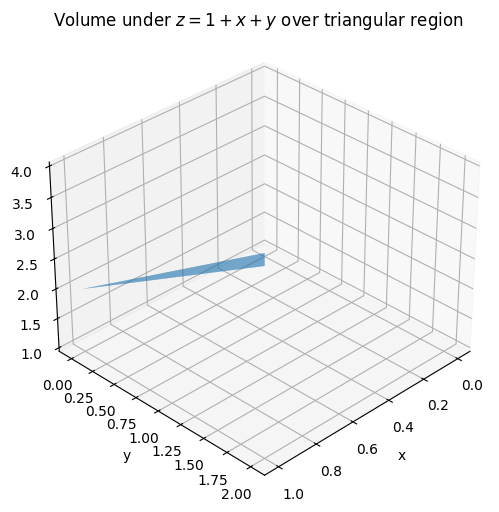

(array([[0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        ...,
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ],
        [0.      , 0.004566, 0.009132, ..., 0.990868, 0.995434, 1.      ]],
       shape=(220, 220)),
 array([[0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.009132, 0.009132, 0.009132, ..., 0.009132, 0.009132, 0.009132],
        [0.018265, 0.018265, 0.018265, ..., 0.018265, 0.018265, 0.018265],
        ...,
        [1.981735, 1.981735, 1.981735, ..., 1.981735, 1.981735, 1.981735],
        [1.990868, 1.990868, 1.990868, ..., 1.990868, 1.990868, 1.990868],
        [2.      , 2.      , 2.      , ..., 2.      , 2.      , 2.      ]],
       shape=(220, 220)),
 array([[1.      , 1

In [18]:
plot_surface_over_mask(
    f_volume,
    tri_mask,
    xmin=0, xmax=1, ymin=0, ymax=2,
    title=r"Volume under $z=1+x+y$ over triangular region"
)

## 13. Average height over the triangular base

The average value is

$$
f_{\text{avg}}=\frac{1}{\text{Area}(D)}\iint_D f(x,y)\,dA.
$$

In [19]:
area_tri, *_ = iterated_type1(one, 0, 1, lambda x: 0*x, lambda x: 2*x, nx=800, ny=80)
avg_height = volume_type1/area_tri

print("Area of triangular base:", area_tri)
print("Average height:", avg_height)

Area of triangular base: 1.0
Average height: 2.3333343776090576


---

# Part VII. Density, mass, and average value

For a lamina occupying region $D$ with density $\rho(x,y)$,

$$
m=\iint_D \rho(x,y)\,dA.
$$

The center of mass is

$$
\bar x=\frac{1}{m}\iint_D x\rho(x,y)\,dA,
\qquad
\bar y=\frac{1}{m}\iint_D y\rho(x,y)\,dA.
$$

## 14. Mass and center of mass on a triangle

Let

$$
D=\{(x,y):0\le x\le1,\;0\le y\le2x\}
$$

with density

$$
\rho(x,y)=1+y.
$$

In [20]:
def rho_tri(X, Y):
    return 1 + Y

mass, *_ = iterated_type1(
    rho_tri,
    0, 1,
    lambda x: 0*x,
    lambda x: 2*x,
    nx=800,
    ny=500
)

moment_y_axis, *_ = iterated_type1(
    lambda X, Y: X*rho_tri(X, Y),
    0, 1,
    lambda x: 0*x,
    lambda x: 2*x,
    nx=800,
    ny=500
)

moment_x_axis, *_ = iterated_type1(
    lambda X, Y: Y*rho_tri(X, Y),
    0, 1,
    lambda x: 0*x,
    lambda x: 2*x,
    nx=800,
    ny=500
)

xbar = moment_y_axis/mass
ybar = moment_x_axis/mass

print("Mass:", mass)
print("Center of mass:", (xbar, ybar))

Mass: 1.6666671888045288
Center of mass: (0.7000005639087146, 0.8000014924323943)


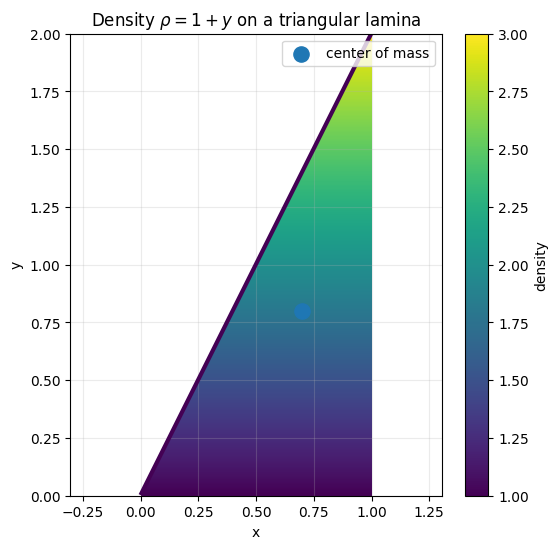

In [21]:
x, y, X, Y = make_grid(0, 1, 0, 2, n=350)
inside = tri_mask(X, Y)
RHO = np.where(inside, rho_tri(X, Y), np.nan)

plt.figure(figsize=(6, 6))
im = plt.imshow(RHO, extent=[0,1,0,2], origin="lower", aspect="auto")
plt.contour(X, Y, inside.astype(float), levels=[0.5], linewidths=3)
plt.scatter([xbar], [ybar], s=120, label="center of mass")
plt.colorbar(im, label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Density $\rho=1+y$ on a triangular lamina")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VIII. Probability over general regions

If $f(x,y)$ is a joint probability density, then

$$
P((X,Y)\in D)=\iint_D f(x,y)\,dA.
$$

General regions appear naturally in events such as:

$$
X+Y\le1,\qquad Y\le X,\qquad X^2+Y^2\le1.
$$

## 15. Uniform density on the unit square

Let $(X,Y)$ be uniform on $[0,1]^2$.  
Find

$$
P(Y\le X^2).
$$

Since the density is $1$ on the unit square,

$$
P(Y\le X^2)=\int_0^1\int_0^{x^2}1\,dy\,dx.
$$

In [22]:
prob_parabola, *_ = iterated_type1(
    one,
    0, 1,
    lambda x: 0*x,
    lambda x: x**2,
    nx=800,
    ny=80
)

print("Probability estimate:", prob_parabola)
print("Exact probability:", 1/3)

plot_type1_region(
    0, 1,
    lambda x: 0*x,
    lambda x: x**2,
    title=r"Event $Y\le X^2$ in the unit square"
)

Probability estimate: 0.3333335944022644
Exact probability: 0.3333333333333333


ValueError: 
Y\le X^2
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x500 with 1 Axes>

## 16. A triangular event with nonuniform density

Let the joint density on the unit square be

$$
f(x,y)=2x,\qquad 0\le x\le1,\quad 0\le y\le1.
$$

This integrates to $1$ over the square.  
Compute

$$
P(Y\le X).
$$

In [23]:
def density_2x(X, Y):
    return 2*X

prob_triangle, *_ = iterated_type1(
    density_2x,
    0, 1,
    lambda x: 0*x,
    lambda x: x,
    nx=800,
    ny=300
)

# Exact: ∫_0^1 ∫_0^x 2x dy dx = ∫_0^1 2x^2 dx = 2/3
print("Probability estimate:", prob_triangle)
print("Exact probability:", 2/3)

plot_type1_region(
    0, 1,
    lambda x: 0*x,
    lambda x: x,
    title=r"Event $Y\le X$ with density $2x$"
)

Probability estimate: 0.6666671888045288
Exact probability: 0.6666666666666666


ValueError: 
Y\le X
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x500 with 1 Axes>

---

# Part IX. Numerical integration over irregular regions

For irregular regions, a mask-based method is often easiest.

If a bounding box contains the region $D$, use midpoint points inside the box and keep only the points satisfying the mask for $D$.

## 17. An irregular region

Consider

$$
D=\{(x,y):-2\le x\le2,\;-2\le y\le2,\;x^2+y^2\le 3+0.8\sin(3x)\cos(2y)\}.
$$

This region is not easy to express with simple iterated limits.

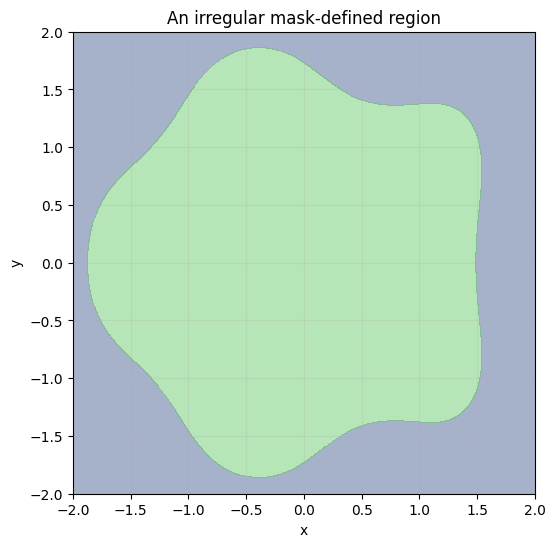

Estimated area: 9.378285714285715
Estimated integral of f: 18.65903283022846
Estimated average value: 1.9895995279612357


In [24]:
def irregular_mask(X, Y):
    return X**2 + Y**2 <= 3 + 0.8*np.sin(3*X)*np.cos(2*Y)

def f_irregular(X, Y):
    return 2 + np.sin(X) + 0.5*np.cos(2*Y)

plot_mask_region(
    irregular_mask,
    -2, 2, -2, 2,
    title="An irregular mask-defined region"
)

area_irreg, Xmid, Ymid, Zmid, inside, dx, dy = midpoint_region(
    one,
    -2, 2, -2, 2,
    irregular_mask,
    nx=700,
    ny=700
)

integral_irreg, *_ = midpoint_region(
    f_irregular,
    -2, 2, -2, 2,
    irregular_mask,
    nx=700,
    ny=700
)

avg_irreg = integral_irreg/area_irreg

print("Estimated area:", area_irreg)
print("Estimated integral of f:", integral_irreg)
print("Estimated average value:", avg_irreg)

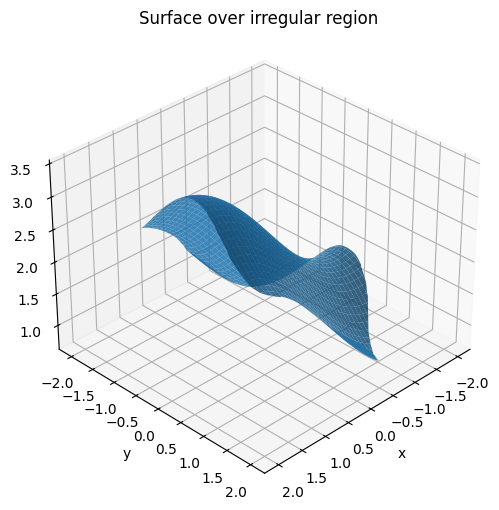

(array([[-2.      , -1.981735, -1.96347 , ...,  1.96347 ,  1.981735,
          2.      ],
        [-2.      , -1.981735, -1.96347 , ...,  1.96347 ,  1.981735,
          2.      ],
        [-2.      , -1.981735, -1.96347 , ...,  1.96347 ,  1.981735,
          2.      ],
        ...,
        [-2.      , -1.981735, -1.96347 , ...,  1.96347 ,  1.981735,
          2.      ],
        [-2.      , -1.981735, -1.96347 , ...,  1.96347 ,  1.981735,
          2.      ],
        [-2.      , -1.981735, -1.96347 , ...,  1.96347 ,  1.981735,
          2.      ]], shape=(220, 220)),
 array([[-2.      , -2.      , -2.      , ..., -2.      , -2.      ,
         -2.      ],
        [-1.981735, -1.981735, -1.981735, ..., -1.981735, -1.981735,
         -1.981735],
        [-1.96347 , -1.96347 , -1.96347 , ..., -1.96347 , -1.96347 ,
         -1.96347 ],
        ...,
        [ 1.96347 ,  1.96347 ,  1.96347 , ...,  1.96347 ,  1.96347 ,
          1.96347 ],
        [ 1.981735,  1.981735,  1.981735, ...,  1.9817

In [25]:
plot_surface_over_mask(
    f_irregular,
    irregular_mask,
    -2, 2, -2, 2,
    title="Surface over irregular region"
)

## 18. Monte Carlo integration over the irregular region

Monte Carlo works by sampling random points in the bounding box and keeping the contribution only for points inside the region.

In [26]:
for n in [5_000, 20_000, 80_000, 250_000]:
    est_area, se_area, *_ = monte_carlo_region(one, -2, 2, -2, 2, irregular_mask, n=n, seed=14+n)
    est_int, se_int, *_ = monte_carlo_region(f_irregular, -2, 2, -2, 2, irregular_mask, n=n, seed=140+n)
    print(f"n={n:8d}  area={est_area:10.6f}  area se={se_area:10.6f}  integral={est_int:10.6f}  int se={se_int:10.6f}")

n=    5000  area=  9.366400  area se=  0.111486  integral= 18.782948  int se=  0.257648
n=   20000  area=  9.266400  area se=  0.055857  integral= 18.697026  int se=  0.128424
n=   80000  area=  9.339800  area se=  0.027885  integral= 18.633355  int se=  0.064204
n=  250000  area=  9.376704  area se=  0.015761  integral= 18.617861  int se=  0.036333


---

# Part X. Computational workflow

A reliable workflow for double integrals over general regions is:

1. draw or plot the region;
2. determine whether vertical or horizontal slices are simpler;
3. write the outer variable range;
4. write the inner limits;
5. evaluate using an iterated integral or numerical grid;
6. check the result using a second method if possible.

## 19. Workflow example: a region bounded by $y=x^2$ and $y=2-x$

First find intersections:

$$
x^2=2-x
\quad\Longrightarrow\quad
x^2+x-2=0
\quad\Longrightarrow\quad
x=-2,\;1.
$$

The Type I region is

$$
-2\le x\le1,\qquad x^2\le y\le 2-x.
$$

Compute

$$
\iint_D (1+x^2+y)\,dA.
$$

In [27]:
def f_workflow(X, Y):
    return 1 + X**2 + Y

workflow_lower = lambda x: x**2
workflow_upper = lambda x: 2 - x

plot_type1_region(
    -2, 1,
    workflow_lower,
    workflow_upper,
    title=r"Workflow example: $x^2\le y\le 2-x$"
)

workflow_val, xs, workflow_inner = iterated_type1(
    f_workflow,
    -2, 1,
    workflow_lower,
    workflow_upper,
    nx=900,
    ny=500
)

workflow_area, *_ = iterated_type1(
    one,
    -2, 1,
    workflow_lower,
    workflow_upper,
    nx=900,
    ny=80
)

print("Integral value:", workflow_val)
print("Area of region:", workflow_area)
print("Average value:", workflow_val/workflow_area)

ValueError: 
x^2\le y\le 2-x
   ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 3), (line:1, col:4)

<Figure size 700x500 with 1 Axes>

Integral value: 14.849966592487554
Area of region: 4.499994432078159
Average value: 3.299996659246895


## 20. Mask-based check for the same workflow example

In [28]:
def workflow_mask(X, Y):
    return (-2 <= X) & (X <= 1) & (X**2 <= Y) & (Y <= 2 - X)

workflow_mask_val, *_ = midpoint_region(
    f_workflow,
    -2, 1, 0, 4.2,
    workflow_mask,
    nx=700,
    ny=700
)

print("Iterated integral value:", workflow_val)
print("Mask midpoint value:", workflow_mask_val)
print("Difference:", workflow_val - workflow_mask_val)

Iterated integral value: 14.849966592487554
Mask midpoint value: 14.846428607772594
Difference: 0.0035379847149599186


---

# Part XI. Chapter mini-project: switch, split, and integrate

In this mini-project, analyze the region

$$
D=\{(x,y):0\le x\le2,\;0\le y\le \min(x,2-x)\}.
$$

This is a triangle with peak at $(1,1)$.

You will:

1. write it as a split Type I region;
2. write it as a Type II region;
3. compute its area;
4. compute the integral of $f(x,y)=x+3y$ over it;
5. compare deterministic and Monte Carlo methods.

## 21. Plot the mini-project region

In [29]:
def mini_mask(X, Y):
    return (0 <= X) & (X <= 2) & (0 <= Y) & (Y <= np.minimum(X, 2-X))

def mini_f(X, Y):
    return X + 3*Y

plot_mask_region(
    mini_mask,
    -0.2, 2.2, -0.2, 1.2,
    title=r"Mini-project region $0\le y\le\min(x,2-x)$"
)

ValueError: 
0\le y\le\min(x,2-x)
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x600 with 1 Axes>

(array([[-0.2     , -0.194655, -0.18931 , ...,  2.18931 ,  2.194655,
          2.2     ],
        [-0.2     , -0.194655, -0.18931 , ...,  2.18931 ,  2.194655,
          2.2     ],
        [-0.2     , -0.194655, -0.18931 , ...,  2.18931 ,  2.194655,
          2.2     ],
        ...,
        [-0.2     , -0.194655, -0.18931 , ...,  2.18931 ,  2.194655,
          2.2     ],
        [-0.2     , -0.194655, -0.18931 , ...,  2.18931 ,  2.194655,
          2.2     ],
        [-0.2     , -0.194655, -0.18931 , ...,  2.18931 ,  2.194655,
          2.2     ]], shape=(450, 450)),
 array([[-0.2     , -0.2     , -0.2     , ..., -0.2     , -0.2     ,
         -0.2     ],
        [-0.196882, -0.196882, -0.196882, ..., -0.196882, -0.196882,
         -0.196882],
        [-0.193764, -0.193764, -0.193764, ..., -0.193764, -0.193764,
         -0.193764],
        ...,
        [ 1.193764,  1.193764,  1.193764, ...,  1.193764,  1.193764,
          1.193764],
        [ 1.196882,  1.196882,  1.196882, ...,  1.1968

## 22. Split Type I calculation

The top boundary changes at $x=1$:

$$
\int_0^1\int_0^x f(x,y)\,dy\,dx
+
\int_1^2\int_0^{2-x} f(x,y)\,dy\,dx.
$$

In [30]:
left_area, *_ = iterated_type1(one, 0, 1, lambda x: 0*x, lambda x: x, nx=500, ny=80)
right_area, *_ = iterated_type1(one, 1, 2, lambda x: 0*x, lambda x: 2-x, nx=500, ny=80)

left_integral, *_ = iterated_type1(mini_f, 0, 1, lambda x: 0*x, lambda x: x, nx=500, ny=400)
right_integral, *_ = iterated_type1(mini_f, 1, 2, lambda x: 0*x, lambda x: 2-x, nx=500, ny=400)

area_split = left_area + right_area
integral_split = left_integral + right_integral

print("Area from split Type I:", area_split)
print("Integral from split Type I:", integral_split)
print("Average value:", integral_split/area_split)

Area from split Type I: 1.0
Integral from split Type I: 2.000002008024064
Average value: 2.000002008024064


## 23. Type II calculation

Horizontal slices are simpler:

$$
0\le y\le1,\qquad y\le x\le 2-y.
$$

So

$$
\iint_D f(x,y)\,dA
=
\int_0^1\int_y^{2-y}f(x,y)\,dx\,dy.
$$

Area from Type II: 1.0
Integral from Type II: 1.9999959839518717
Difference in integral: 6.024072192190033e-06


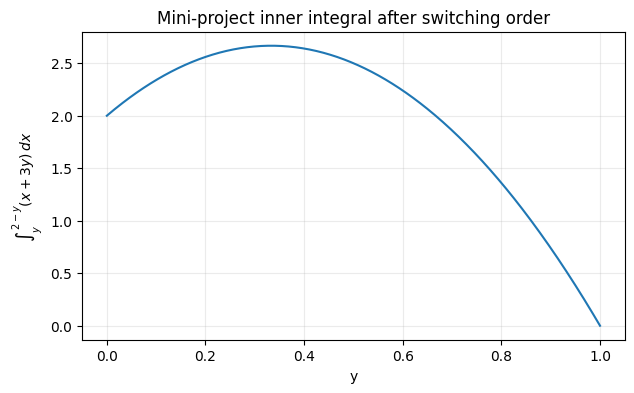

In [31]:
area_type2_mini, *_ = iterated_type2(one, 0, 1, lambda y: y, lambda y: 2-y, ny=500, nx=80)
integral_type2_mini, ys, inner_mini = iterated_type2(mini_f, 0, 1, lambda y: y, lambda y: 2-y, ny=500, nx=400)

print("Area from Type II:", area_type2_mini)
print("Integral from Type II:", integral_type2_mini)
print("Difference in integral:", integral_split - integral_type2_mini)

plt.figure(figsize=(7, 4))
plt.plot(ys, inner_mini)
plt.xlabel("y")
plt.ylabel(r"$\int_y^{2-y}(x+3y)\,dx$")
plt.title("Mini-project inner integral after switching order")
plt.grid(True, alpha=0.25)
plt.show()

## 24. Monte Carlo check

In [32]:
for n in [5_000, 20_000, 100_000, 300_000]:
    est, se, *_ = monte_carlo_region(mini_f, 0, 2, 0, 1, mini_mask, n=n, seed=1400+n)
    print(f"n={n:8d}, estimate={est:.8f}, standard error={se:.8f}, error vs Type II={est-integral_type2_mini:.8f}")

n=    5000, estimate=1.94330592, standard error=0.03237067, error vs Type II=-0.05669006
n=   20000, estimate=2.00200890, standard error=0.01635428, error vs Type II=0.00201292
n=  100000, estimate=2.00023234, standard error=0.00729222, error vs Type II=0.00023635
n=  300000, estimate=2.01093839, standard error=0.00422570, error vs Type II=0.01094241


## 25. Mini-project questions

Answer the following in a markdown cell:

1. Why does the Type I description require splitting?
2. Why is the Type II description simpler?
3. What is the area of the region?
4. What is the average value of $x+3y$ over the region?
5. Which computational method would you use if the region boundary came from data rather than formulas?

In [33]:
print("Mini-project summary")
print("--------------------")
print("Area:", area_type2_mini)
print("Integral of x+3y:", integral_type2_mini)
print("Average value:", integral_type2_mini/area_type2_mini)
print("Split Type I agrees with Type II:", np.isclose(integral_split, integral_type2_mini, rtol=1e-4))

Mini-project summary
--------------------
Area: 1.0
Integral of x+3y: 1.9999959839518717
Average value: 1.9999959839518717
Split Type I agrees with Type II: True


---

# Part XII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Type I setup and area

Find the area of

$$
D=\{(x,y):0\le x\le2,\;x\le y\le 2x\}.
$$

In [34]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [35]:
area_A, *_ = iterated_type1(one, 0, 2, lambda x: x, lambda x: 2*x, nx=600, ny=80)
print("Area:", area_A)
print("Exact area:", 2.0)

Area: 2.0
Exact area: 2.0


## Exercise B. Type II setup

Evaluate

$$
\int_0^1\int_{y^2}^{1} (x+y)\,dx\,dy.
$$

In [36]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [37]:
val_B, *_ = iterated_type2(f_sum, 0, 1, lambda y: y**2, lambda y: 1 + 0*y, ny=700, nx=500)
print("Numerical value:", val_B)

# Exact:
# ∫_0^1 [x^2/2 + yx]_{y^2}^{1} dy
# = ∫_0^1 (1/2 + y - y^4/2 - y^3) dy
# = 1/2 + 1/2 - 1/10 - 1/4 = 13/20
print("Exact value:", 13/20)

Numerical value: 0.6499991472251745
Exact value: 0.65


## Exercise C. Reverse the order

Reverse the order of integration for

$$
\int_0^1\int_x^1 e^{y^2}\,dy\,dx.
$$

Then compute the value numerically.

In [38]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [39]:
# Region: 0 <= x <= 1, x <= y <= 1.
# Reversed: 0 <= y <= 1, 0 <= x <= y.
val_C_reversed, *_ = iterated_type2(
    f_exp_y2,
    0, 1,
    lambda y: 0*y,
    lambda y: y,
    ny=1000,
    nx=80
)

# Direct reduced one-dimensional form: ∫_0^1 y e^{y^2} dy = (e-1)/2
print("Reversed-order numerical value:", val_C_reversed)
print("Exact value:", (np.e - 1)/2)

Reversed-order numerical value: 0.859141511660776
Exact value: 0.8591409142295225


## Exercise D. Split a region

Compute

$$
\iint_D (1+y)\,dA
$$

where

$$
D=\{(x,y):-1\le x\le1,\;0\le y\le 1-x^2\}.
$$

In [40]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [41]:
def f_D(X, Y):
    return 1 + Y

val_D, *_ = iterated_type1(
    f_D,
    -1, 1,
    lambda x: 0*x,
    lambda x: 1 - x**2,
    nx=900,
    ny=500
)

print("Numerical value:", val_D)

# Exact:
# ∫_{-1}^1 [(1-x^2) + (1-x^2)^2/2] dx
x_dense = np.linspace(-1, 1, 3000)
exact_D = np.trapezoid((1-x_dense**2) + 0.5*(1-x_dense**2)**2, x_dense)
print("High-resolution exact/numerical 1D value:", exact_D)

Numerical value: 1.8666650169112307
High-resolution exact/numerical 1D value: 1.8666665184196973


## Exercise E. Probability

Let $(X,Y)$ have density

$$
f(x,y)=6xy
$$

on the triangle

$$
0\le y\le x\le1.
$$

First verify that this is a probability density.  
Then compute

$$
P(Y\le 1/2).
$$

In [42]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [43]:
def density_E(X, Y):
    return 6*X*Y

# Total probability on 0 <= y <= x <= 1
total_E, *_ = iterated_type1(density_E, 0, 1, lambda x: 0*x, lambda x: x, nx=800, ny=500)

# Event y <= 1/2; split x from 0 to 1/2 with y in [0,x],
# and x from 1/2 to 1 with y in [0,1/2].
part1, *_ = iterated_type1(density_E, 0, 0.5, lambda x: 0*x, lambda x: x, nx=400, ny=400)
part2, *_ = iterated_type1(density_E, 0.5, 1, lambda x: 0*x, lambda x: 0.5 + 0*x, nx=400, ny=400)
prob_E = part1 + part2

print("Total probability:", total_E)
print("P(Y <= 1/2):", prob_E)

Total probability: 0.7500011748101898
P(Y <= 1/2): 0.32812529443910526


---

# Formula summary

## Type I region

$$
D=\{(x,y):a\le x\le b,\;p(x)\le y\le q(x)\}.
$$

Then

$$
\iint_D f(x,y)\,dA
=
\int_a^b\int_{p(x)}^{q(x)} f(x,y)\,dy\,dx.
$$

## Type II region

$$
D=\{(x,y):c\le y\le d,\;g(y)\le x\le h(y)\}.
$$

Then

$$
\iint_D f(x,y)\,dA
=
\int_c^d\int_{g(y)}^{h(y)} f(x,y)\,dx\,dy.
$$

## Area

$$
\operatorname{Area}(D)=\iint_D1\,dA.
$$

## Average value

$$
f_{\operatorname{avg}}
=
\frac{1}{\operatorname{Area}(D)}
\iint_D f(x,y)\,dA.
$$

## Mass and center of mass

$$
m=\iint_D\rho(x,y)\,dA,
$$

$$
\bar x=\frac{1}{m}\iint_D x\rho(x,y)\,dA,
\qquad
\bar y=\frac{1}{m}\iint_D y\rho(x,y)\,dA.
$$

## Probability

If $f$ is a joint density, then

$$
P((X,Y)\in D)=\iint_D f(x,y)\,dA.
$$

## Mask-based approximation

For a bounding box $B$ containing $D$,

$$
\iint_D f\,dA
\approx
\sum_{(x_i,y_j)\in D} f(x_i,y_j)\Delta A.
$$

## Monte Carlo approximation

$$
\iint_D f\,dA
=
\operatorname{Area}(B)\,
\mathbb E[f(X,Y)\mathbf 1_D(X,Y)].
$$

# End of Chapter 14 Lab

You have used Python to explore:

- Type I and Type II regions,
- variable limits of integration,
- reversing the order of integration,
- splitting regions,
- area and average value,
- volume over curved bases,
- density and center of mass,
- probability over general events,
- mask-based numerical integration,
- Monte Carlo integration,
- and a switch/split/integrate mini-project.

These ideas prepare for polar coordinates, change of variables, triple integrals, probability densities, vector calculus, and flux integrals.